In [ ]:
!pip install -q transformers

!pip install -q datasets

!pip install -q librosa

!pip install -q soundfile

!pip install -q accelerate

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
import torch
from IPython.display import Audio, display
from google.colab import files
from transformers import pipeline, WhisperProcessor, WhisperForConditionalGeneration

np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo disponible:", device)

Dispositivo disponible: cpu


In [ ]:
# Cargamos el archivo de audio
uploaded=files.upload()
audio_path=list(uploaded.keys())[0]

print("Archivo cargado:",audio_path)

Saving Miros place.m4a to Miros place.m4a
Archivo cargado: Miros place.m4a


In [ ]:
# Cargamos audio con librosa
target_sr = 16000

audio, sr = librosa.load(audio_path, sr=target_sr)

duracion_segundos = len(audio)/sr

print("Sample rate:", sr)
print("Numero de muestras:", len(audio))
print("Duracion en segundos:", duracion_segundos)

print("\nAudio original")
display(Audio(audio, rate=sr))

/tmp/ipykernel_7662/650441397.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_path, sr=target_sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sample rate: 16000
Numero de muestras: 107862
Duracion en segundos: 6.741375

Audio original


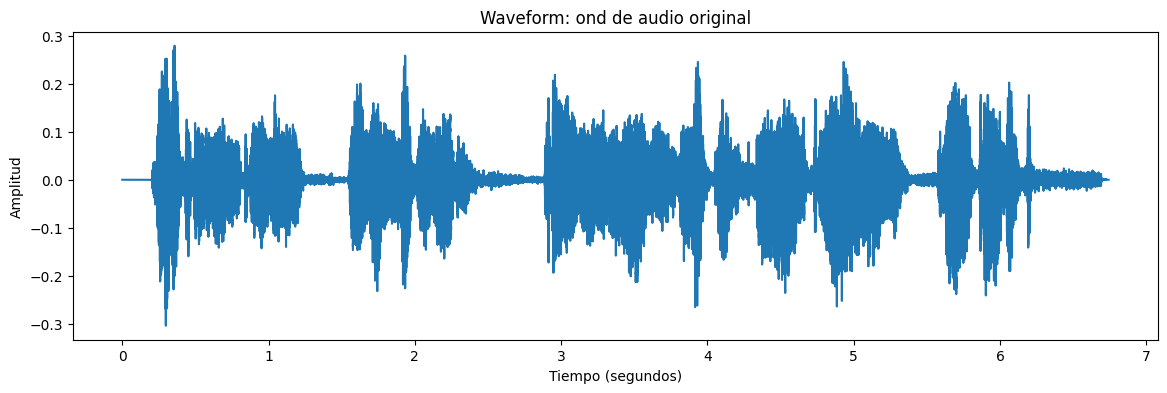

In [ ]:
# Vizualizamos la onda de audio

tiempo= np.linspace(
    0,
    duracion_segundos,
    num=len(audio)
)

plt.figure(figsize=(14,4))
plt.plot(tiempo, audio)
plt.title("Waveform: ond de audio original")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Amplitud")
plt.show()

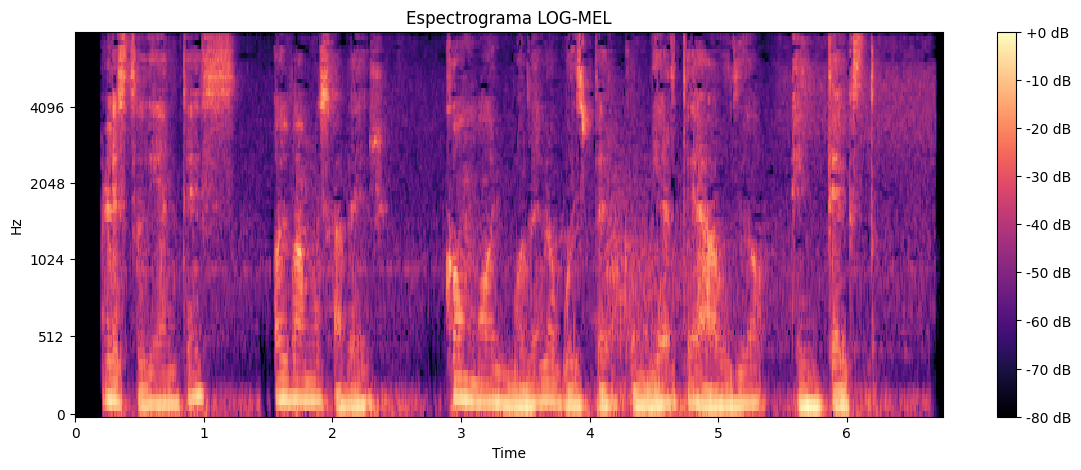

In [ ]:
# Creamos el espectograma LOG-MEL
mel_espec=librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=80,
    n_fft=400,
    hop_length=160
)

log_mel_spec = librosa.power_to_db(
    mel_espec,
    ref=np.max
)

plt.figure(figsize=(14,5))

librosa.display.specshow(
    log_mel_spec,
    sr=sr,
    hop_length=160,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma LOG-MEL")
plt.show()

In [ ]:
# Cargamos a whisper el audio(espectrograma)
modelo_whisper= "openai/whisper-base"

processor=WhisperProcessor.from_pretrained(modelo_whisper)

model= WhisperForConditionalGeneration.from_pretrained(modelo_whisper)

model=model.to(device)

model.eval()

print("Whisper cargado correctamente")
print("Modelo usado:", modelo_whisper)
print("Dispositivo:",device)

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Whisper cargado correctamente
Modelo usado: openai/whisper-base
Dispositivo: cpu


In [ ]:
# Transcribimos el audio
inputs=processor(audio, return_tensors="pt", sampling_rate=sr)
input_features= inputs.input_features
input_features = input_features.to(device)

with torch.no_grad():
  predicted_ids=model.generate(input_features)

print("\nForma de predicted_ids:", predicted_ids.shape)
print("\nIDs generados:")
print(predicted_ids[0])

transcripcion = processor.batch_decode(
    predicted_ids,
    skip_special_tokens=True

    )
print("\nTranscripcion generada por Whisper:")
print(transcripcion[0])

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.log


Forma de predicted_ids: torch.Size([1, 23])

IDs generados:
tensor([ 3841,    47,   495,   532, 20135,    30, 28664,  5295,   257,  1306,
        12826,   806, 27825,   343,  7631,   433,  3754, 23123,   257,  6278,
          465, 35503,    13])

Transcripcion generada por Whisper:
 ¿Presudientes? Hoy vamos a ver cómo el modelo Wispers convierte a audio en texto.


In [ ]:
# Forzaremos el idioma
forced_decoder_ids= processor.get_decoder_prompt_ids(
    language="english",
    task="translate"
)

print("Forced decoder IDs:")
print(forced_decoder_ids)

with torch.no_grad():
  predicted_ids_es = model.generate(
      input_features,
      forced_decoder_ids=forced_decoder_ids
  )

transcripcion_es = processor.batch_decode(
      predicted_ids_es,
      skip_special_tokens=True

  )

print("\nTranscripcion forzando idioma español:")
print(transcripcion_es[0])

Forced decoder IDs:
[(1, 50259), (2, 50358), (3, 50363)]

Transcripcion forzando idioma español:
 Students, today we will see how the model will be able to get you to audio in text.
